# 4. Experimentation

This notebook trains, evaluates, and compares multiple regression models for house price prediction.

**Steps:**
1. Load feature-ready data
2. Train/test split
3. Train baseline model
4. Train and compare multiple models
5. Hyperparameter tuning for best model
6. Final evaluation and model selection
7. Save best model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
import time

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42

## 4.1 Load Feature-Ready Data

In [2]:
df = pd.read_csv('../shared/data/features/house_data_features.csv')

with open('../shared/data/features/feature_list.json', 'r') as f:
    FEATURE_COLS = json.load(f)

X = df[FEATURE_COLS]
y = df['log_price']  # Use log-transformed target
y_original = df['price']  # Keep original for final metrics

print(f'Feature matrix: {X.shape}')
print(f'Target vector: {y.shape}')
print(f'Features: {FEATURE_COLS}')

Feature matrix: (84, 17)
Target vector: (84,)
Features: ['sqft', 'bedrooms', 'bathrooms', 'year_built', 'house_age', 'loc_Downtown', 'loc_Mountain', 'loc_Rural', 'loc_Suburb', 'loc_Urban', 'loc_Waterfront', 'condition_encoded', 'total_rooms', 'bath_bed_ratio', 'is_luxury', 'is_new', 'sqft_per_bedroom']


## 4.2 Train/Test Split

In [3]:
X_train, X_test, y_train, y_test, y_train_orig, y_test_orig = train_test_split(
    X, y, y_original, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nTarget distribution:')
print(f'  Train - mean: ${np.expm1(y_train).mean():,.0f}, std: ${np.expm1(y_train).std():,.0f}')
print(f'  Test  - mean: ${np.expm1(y_test).mean():,.0f}, std: ${np.expm1(y_test).std():,.0f}')

Training set: 67 samples
Test set: 17 samples

Target distribution:
  Train - mean: $627,541, std: $330,399
  Test  - mean: $552,118, std: $283,114


## 4.3 Define Evaluation Metrics

In [4]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """Evaluate model and return metrics dictionary."""
    # Predict on log scale
    y_pred_train_log = model.predict(X_train)
    y_pred_test_log = model.predict(X_test)
    
    # Convert back to original scale for interpretability
    y_pred_train = np.expm1(y_pred_train_log)
    y_pred_test = np.expm1(y_pred_test_log)
    y_train_orig_local = np.expm1(y_train)
    y_test_orig_local = np.expm1(y_test)
    
    metrics = {
        'Model': model_name,
        'Train_R2': r2_score(y_train_orig_local, y_pred_train),
        'Test_R2': r2_score(y_test_orig_local, y_pred_test),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train_orig_local, y_pred_train)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test_orig_local, y_pred_test)),
        'Train_MAE': mean_absolute_error(y_train_orig_local, y_pred_train),
        'Test_MAE': mean_absolute_error(y_test_orig_local, y_pred_test),
        'Train_MAPE': mean_absolute_percentage_error(y_train_orig_local, y_pred_train),
        'Test_MAPE': mean_absolute_percentage_error(y_test_orig_local, y_pred_test),
    }
    
    return metrics, y_pred_test

def print_metrics(metrics):
    """Pretty print model metrics."""
    print(f"\n{'='*50}")
    print(f"Model: {metrics['Model']}")
    print(f"{'='*50}")
    print(f"  Train R2:   {metrics['Train_R2']:.4f}")
    print(f"  Test  R2:   {metrics['Test_R2']:.4f}")
    print(f"  Train RMSE: ${metrics['Train_RMSE']:>12,.2f}")
    print(f"  Test  RMSE: ${metrics['Test_RMSE']:>12,.2f}")
    print(f"  Train MAE:  ${metrics['Train_MAE']:>12,.2f}")
    print(f"  Test  MAE:  ${metrics['Test_MAE']:>12,.2f}")
    print(f"  Train MAPE: {metrics['Train_MAPE']:.4f}")
    print(f"  Test  MAPE: {metrics['Test_MAPE']:.4f}")

## 4.4 Train Baseline: Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_metrics, lr_preds = evaluate_model(lr, X_train, X_test, y_train, y_test, "Linear Regression")
print_metrics(lr_metrics)


Model: Linear Regression
  Train R2:   0.9974
  Test  R2:   0.9533
  Train RMSE: $   16,771.95
  Test  RMSE: $   59,350.41
  Train MAE:  $   11,258.40
  Test  MAE:  $   32,088.44
  Train MAPE: 0.0163
  Test  MAPE: 0.0525


## 4.5 Train Multiple Models

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'SVR': SVR(kernel='rbf', C=100, epsilon=0.1),
}

all_metrics = []
all_predictions = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    metrics, preds = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    metrics['Train_Time(s)'] = round(train_time, 3)
    all_metrics.append(metrics)
    all_predictions[name] = preds
    print(f'{name:25s} | Test R2: {metrics["Test_R2"]:.4f} | Test RMSE: ${metrics["Test_RMSE"]:>12,.0f} | Time: {train_time:.3f}s')

Linear Regression         | Test R2: 0.9533 | Test RMSE: $      59,350 | Time: 0.003s
Ridge                     | Test R2: 0.9593 | Test RMSE: $      55,402 | Time: 0.007s
Lasso                     | Test R2: 0.8936 | Test RMSE: $      89,607 | Time: 0.005s
ElasticNet                | Test R2: 0.9270 | Test RMSE: $      74,191 | Time: 0.003s
Random Forest             | Test R2: 0.9226 | Test RMSE: $      76,430 | Time: 0.186s
Gradient Boosting         | Test R2: 0.9560 | Test RMSE: $      57,583 | Time: 0.092s
SVR                       | Test R2: 0.8069 | Test RMSE: $     120,696 | Time: 0.004s


In [7]:
# Results comparison table
results_df = pd.DataFrame(all_metrics)
results_df = results_df.sort_values('Test_R2', ascending=False)
results_df[['Model', 'Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE', 'Test_MAE', 'Test_MAPE', 'Train_Time(s)']].round(4)

,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Test_MAE,Test_MAPE,Train_Time(s)
1,Ridge,0.9879,0.9593,36028.5354,55401.5513,32140.2100,0.0502,0.007
5,Gradient Boosting,0.9999,0.9560,2733.5993,57582.5134,31835.7336,0.0526,0.092
0,Linear Regression,0.9974,0.9533,16771.9459,59350.4134,32088.4389,0.0525,0.003
3,ElasticNet,0.9732,0.9270,53644.7226,74191.0454,43038.3311,0.0667,0.003
4,Random Forest,0.9996,0.9226,6315.7553,76429.8491,42741.3962,0.0616,0.186
2,Lasso,0.9595,0.8936,65961.4754,89606.5715,56515.5029,0.0870,0.005
6,SVR,0.8465,0.8069,128479.5948,120695.6997,71900.0665,0.1145,0.004


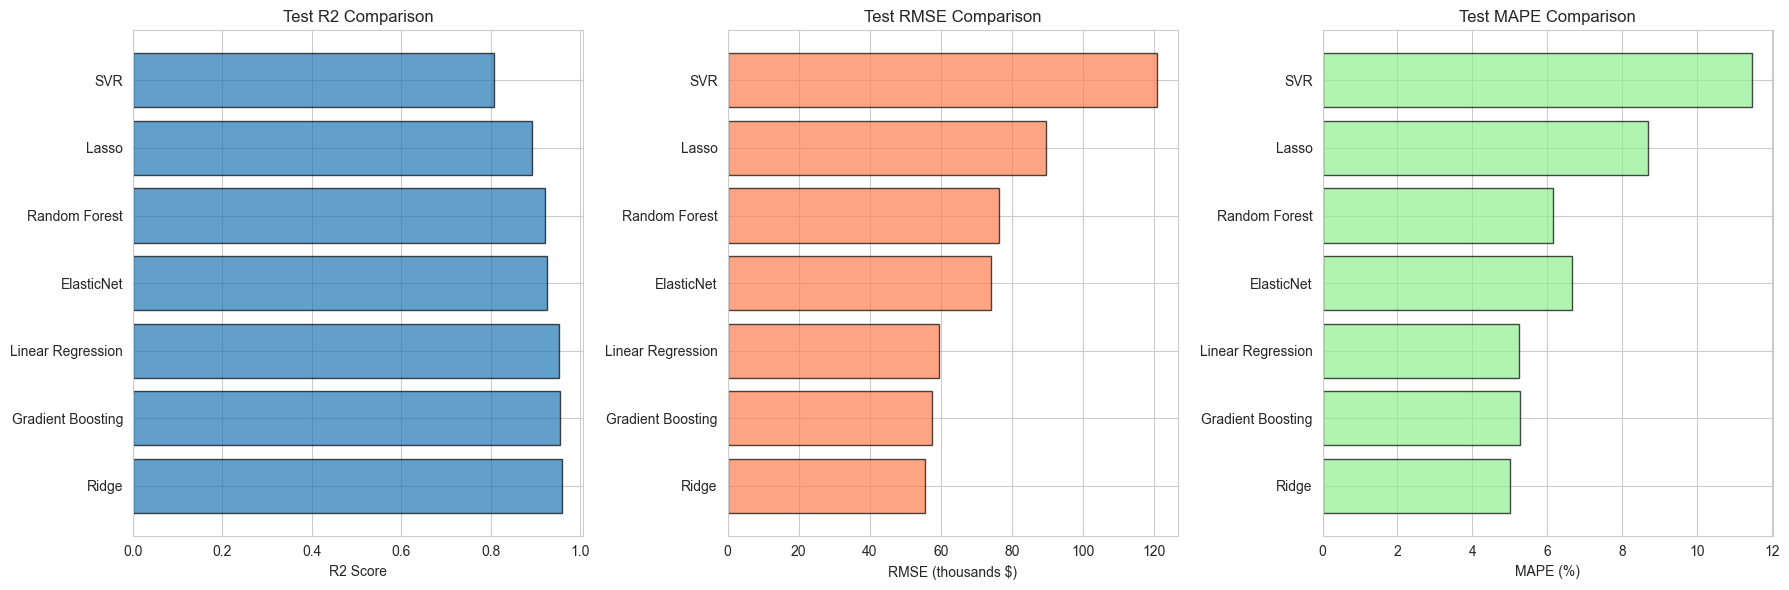

In [8]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_names = results_df['Model'].values
x_pos = np.arange(len(models_names))

# R2 Comparison
axes[0].barh(x_pos, results_df['Test_R2'].values, edgecolor='black', alpha=0.7)
axes[0].set_yticks(x_pos)
axes[0].set_yticklabels(models_names)
axes[0].set_xlabel('R2 Score')
axes[0].set_title('Test R2 Comparison')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# RMSE Comparison
axes[1].barh(x_pos, results_df['Test_RMSE'].values / 1000, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(models_names)
axes[1].set_xlabel('RMSE (thousands $)')
axes[1].set_title('Test RMSE Comparison')

# MAPE Comparison
axes[2].barh(x_pos, results_df['Test_MAPE'].values * 100, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].set_yticks(x_pos)
axes[2].set_yticklabels(models_names)
axes[2].set_xlabel('MAPE (%)')
axes[2].set_title('Test MAPE Comparison')

plt.tight_layout()
plt.show()

## 4.6 Cross-Validation for Top Models

Cross-validating top 3 models: ['Ridge' 'Gradient Boosting' 'Linear Regression']

Ridge                     | CV R2: 0.9848 (+/- 0.0156)
Gradient Boosting         | CV R2: 0.9922 (+/- 0.0108)
Linear Regression         | CV R2: 0.9912 (+/- 0.0100)


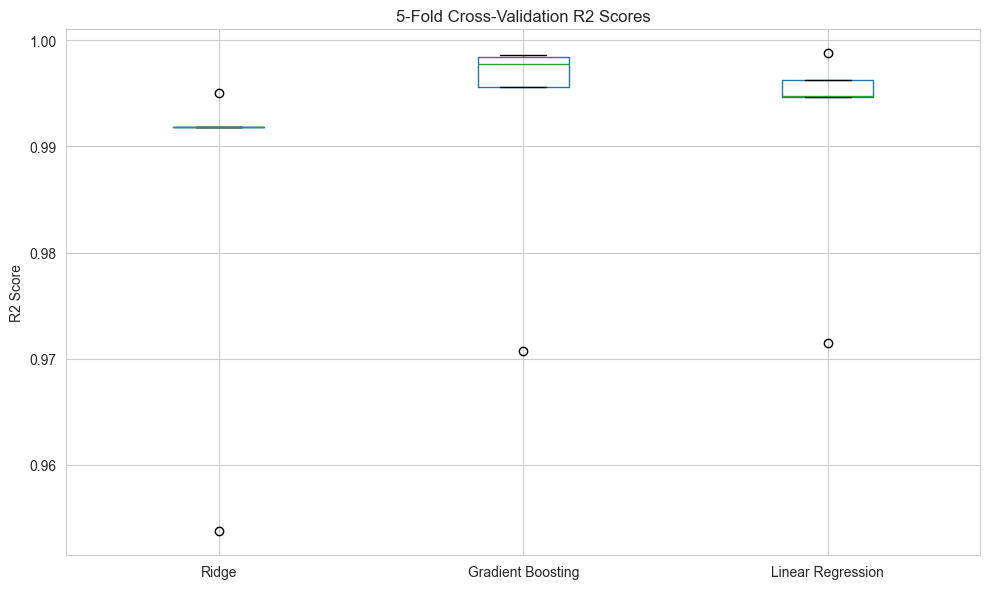

In [9]:
top_models = results_df.head(3)['Model'].values
print(f'Cross-validating top 3 models: {top_models}\n')

cv_results = {}
for name in top_models:
    model = models[name]
    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | CV R2: {scores.mean():.4f} (+/- {scores.std():.4f})')

# Box plot of CV results
cv_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(10, 6))
cv_df.boxplot(ax=ax)
ax.set_title('5-Fold Cross-Validation R2 Scores')
ax.set_ylabel('R2 Score')
plt.tight_layout()
plt.show()

## 4.7 Hyperparameter Tuning - Best Model

In [10]:
# Select best model from CV results
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Best model from CV: {best_model_name}')

Best model from CV: Gradient Boosting


In [11]:
# Define hyperparameter grids based on best model
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'min_samples_split': [2, 5, 10]
    },
    'Ridge': {
        'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Lasso': {
        'alpha': [0.001, 0.01, 0.1, 1.0]
    },
    'Linear Regression': {},
    'ElasticNet': {
        'alpha': [0.001, 0.01, 0.1, 1.0],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR': {
        'C': [1, 10, 100, 1000],
        'epsilon': [0.01, 0.1, 0.5],
        'kernel': ['rbf', 'linear']
    }
}

if param_grids.get(best_model_name):
    print(f'Running GridSearchCV for {best_model_name}...')
    grid_search = GridSearchCV(
        models[best_model_name],
        param_grids[best_model_name],
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    print(f'\nBest parameters: {grid_search.best_params_}')
    print(f'Best CV R2: {grid_search.best_score_:.4f}')
    
    best_model = grid_search.best_estimator_
else:
    print(f'No hyperparameter grid for {best_model_name}. Using default params.')
    best_model = models[best_model_name]

Running GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.9984


## 4.8 Final Model Evaluation

In [12]:
final_metrics, final_preds = evaluate_model(
    best_model, X_train, X_test, y_train, y_test, f'{best_model_name} (Tuned)'
)
print_metrics(final_metrics)


Model: Gradient Boosting (Tuned)
  Train R2:   0.9999
  Test  R2:   0.9489
  Train RMSE: $    2,500.82
  Test  RMSE: $   62,092.50
  Train MAE:  $      805.97
  Test  MAE:  $   38,910.69
  Train MAPE: 0.0016
  Test  MAPE: 0.0581


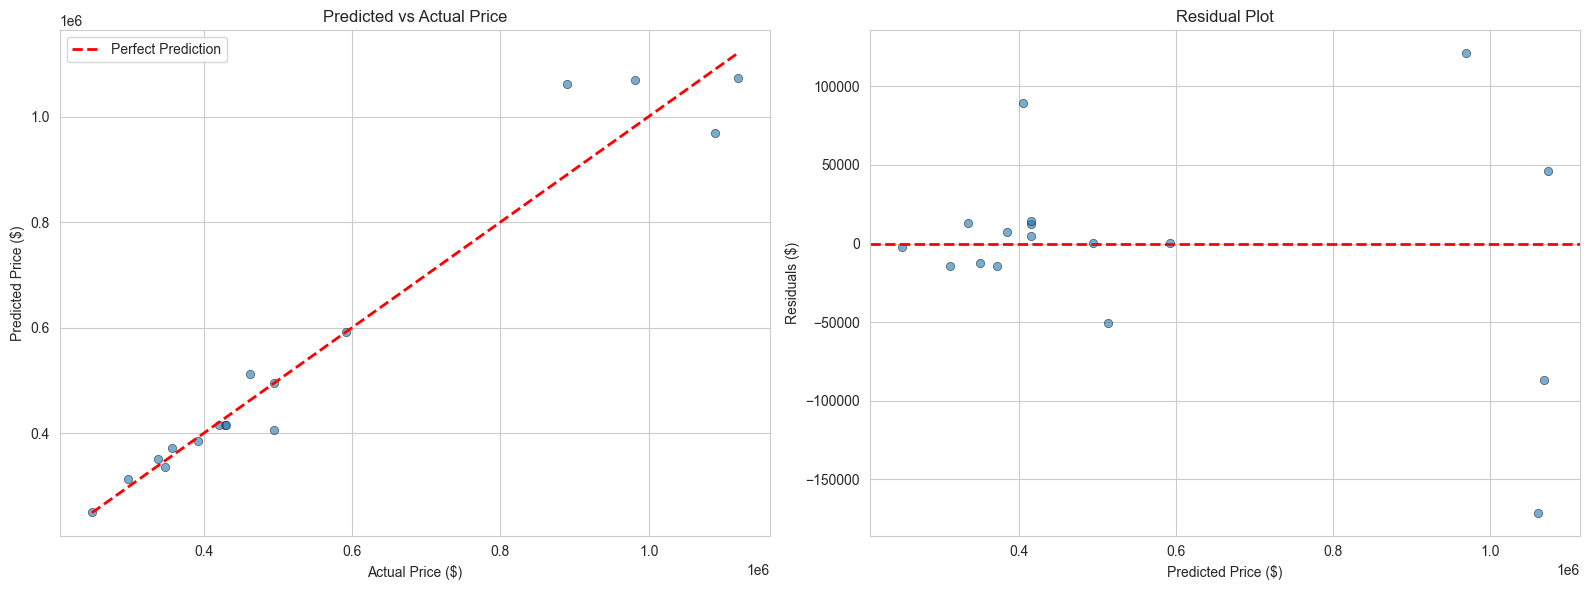


Residual Statistics:
  Mean: $   -2,553.01
  Std:  $   63,949.36
  Min:  $ -171,335.62
  Max:  $  121,069.62


In [13]:
# Predicted vs Actual plot
y_test_orig_vals = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test_orig_vals, final_preds, alpha=0.6, edgecolor='k', linewidth=0.5)
min_val = min(y_test_orig_vals.min(), final_preds.min())
max_val = max(y_test_orig_vals.max(), final_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs Actual Price')
axes[0].legend()

# Residual plot
residuals = y_test_orig_vals - final_preds
axes[1].scatter(final_preds, residuals, alpha=0.6, edgecolor='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

print(f'\nResidual Statistics:')
print(f'  Mean: ${residuals.mean():>12,.2f}')
print(f'  Std:  ${residuals.std():>12,.2f}')
print(f'  Min:  ${residuals.min():>12,.2f}')
print(f'  Max:  ${residuals.max():>12,.2f}')

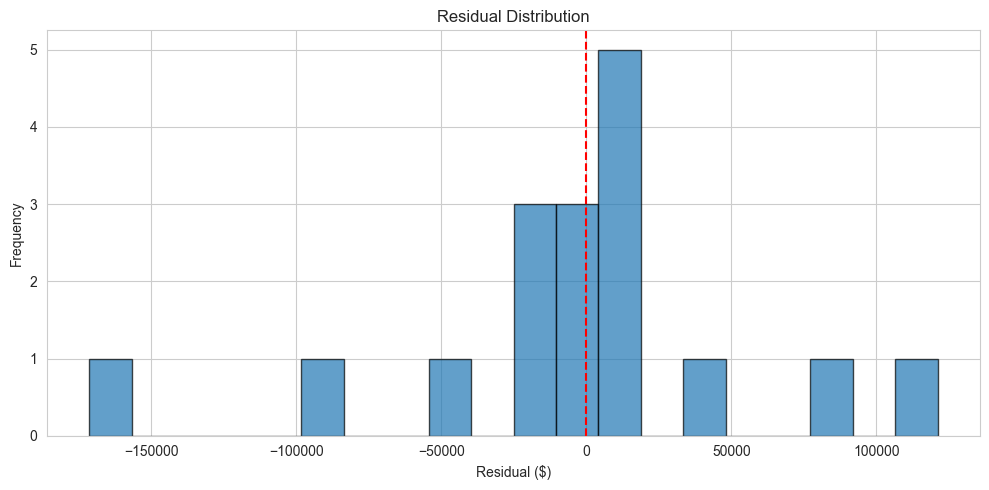

In [14]:
# Residual distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Frequency')
ax.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

## 4.9 Feature Importance (Tree-Based Models)

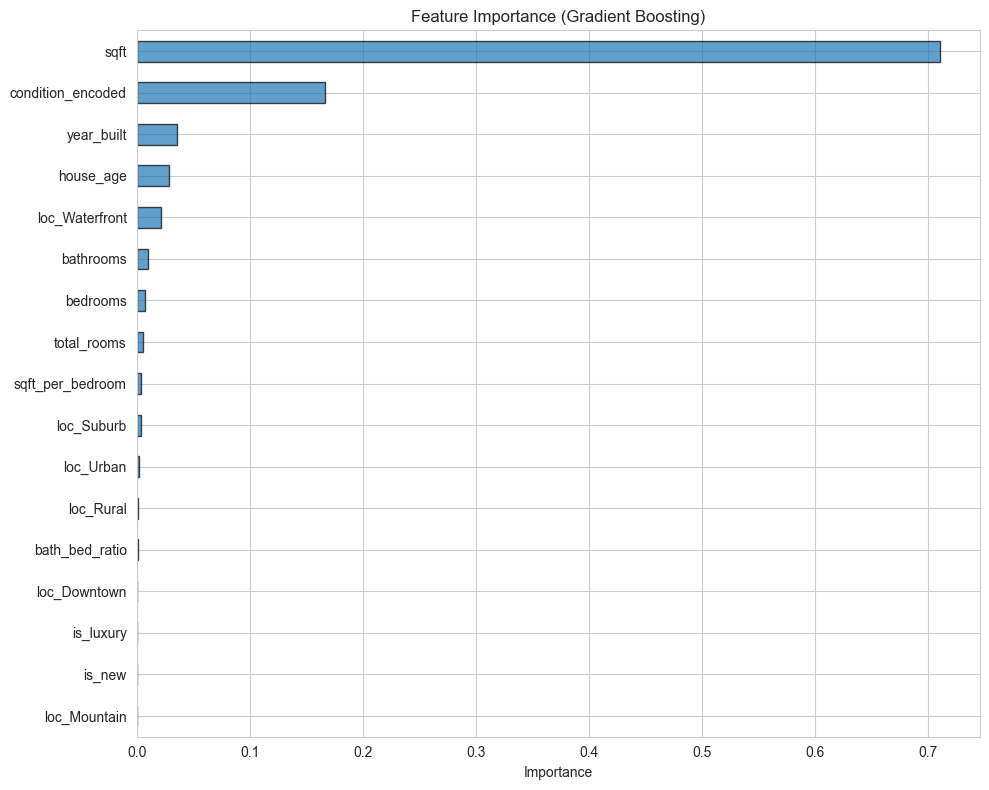

In [15]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    importances.plot(kind='barh', ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Feature Importance ({best_model_name})')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(np.abs(best_model.coef_), index=FEATURE_COLS)
    coefs = coefs.sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    coefs.plot(kind='barh', ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Feature Coefficients ({best_model_name})')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()
else:
    print('Model does not expose feature importance or coefficients.')

## 4.10 Save Best Model and Experiment Results

In [16]:
# Save the best model
models_dir = '../shared/models'
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'best_model.joblib')
joblib.dump(best_model, model_path)
print(f'Saved best model to {model_path}')

# Save experiment results
experiment_results = {
    'best_model': best_model_name,
    'best_params': grid_search.best_params_ if param_grids.get(best_model_name) else {},
    'best_cv_r2': float(grid_search.best_score_) if param_grids.get(best_model_name) else float(cv_results[best_model_name].mean()),
    'final_metrics': final_metrics,
    'all_model_results': all_metrics,
    'features_used': FEATURE_COLS,
    'target': 'log_price (log-transformed)'
}

results_path = os.path.join(models_dir, 'experiment_results.json')
with open(results_path, 'w') as f:
    json.dump(experiment_results, f, indent=2, default=str)
print(f'Saved experiment results to {results_path}')

Saved best model to ../shared/models\best_model.joblib
Saved experiment results to ../shared/models\experiment_results.json


In [17]:
# Summary
print('\n' + '='*60)
print('EXPERIMENT SUMMARY')
print('='*60)
print(f'Best Model: {best_model_name}')
print(f'Best Test R2: {final_metrics["Test_R2"]:.4f}')
print(f'Best Test RMSE: ${final_metrics["Test_RMSE"]:,.2f}')
print(f'Best Test MAE: ${final_metrics["Test_MAE"]:,.2f}')
print(f'Best Test MAPE: {final_metrics["Test_MAPE"]*100:.2f}%')
print(f'Number of features: {len(FEATURE_COLS)}')
print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print('='*60)


EXPERIMENT SUMMARY
Best Model: Gradient Boosting
Best Test R2: 0.9489
Best Test RMSE: $62,092.50
Best Test MAE: $38,910.69
Best Test MAPE: 5.81%
Number of features: 17
Training samples: 67
Test samples: 17
